# Artist-Attribution Classifier

RoBERTa-base fine-tuned for 5-class artist classification. Generates report figures from training results.

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
set_seed(SEED)

os.makedirs("../report/figures", exist_ok=True)

## Data

In [2]:
train_df = pd.read_csv("data/train.csv")
eval_df = pd.read_csv("data/eval.csv")

label2id = {name: i for i, name in enumerate(sorted(train_df["artist"].unique()))}
id2label = {i: name for name, i in label2id.items()}
artists = [id2label[i] for i in range(len(id2label))]

print(f"Train: {len(train_df)}, Eval: {len(eval_df)}")
print(f"Labels: {label2id}")

Train: 459, Eval: 51
Labels: {'Death': 0, 'Gojira': 1, 'Meshuggah': 2, 'Opeth': 3, 'Tool': 4}


## Dataset figures

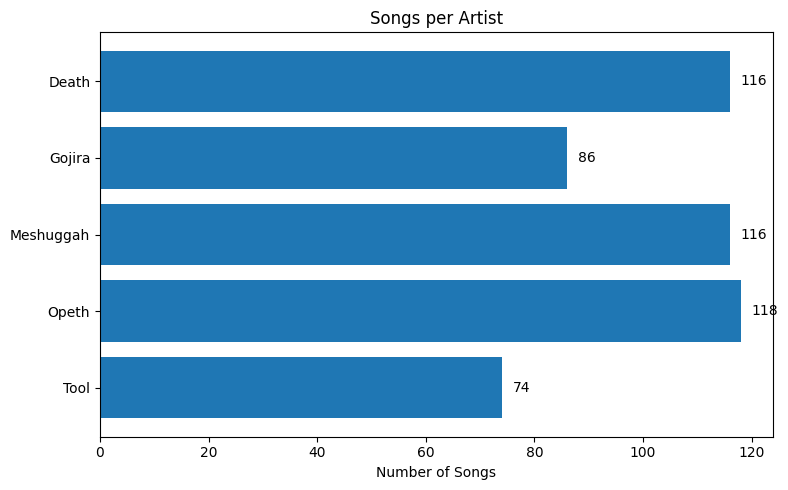

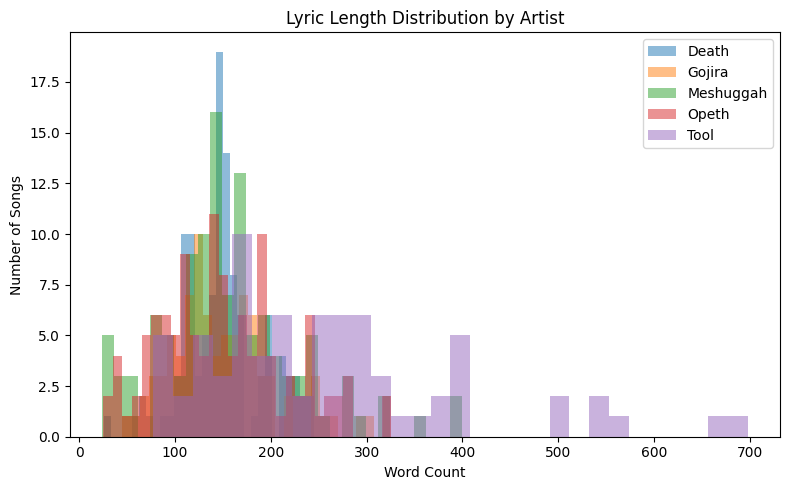

In [3]:
all_df = pd.concat([train_df, eval_df])

# Artist distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = all_df["artist"].value_counts().reindex(artists)
ax.barh(artists, counts.values)
ax.set_xlabel("Number of Songs")
ax.set_title("Songs per Artist")
ax.invert_yaxis()
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(v), va="center")
plt.tight_layout()
plt.savefig("../report/figures/artist_distribution.pdf", bbox_inches="tight")
plt.show()

# Lyric length distribution
fig, ax = plt.subplots(figsize=(8, 5))
for artist in artists:
    lengths = all_df[all_df["artist"] == artist]["clean"].str.split().str.len()
    ax.hist(lengths, bins=30, alpha=0.5, label=artist)
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Songs")
ax.set_title("Lyric Length Distribution by Artist")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/lyric_lengths.pdf", bbox_inches="tight")
plt.show()

## Tokenize

In [4]:
model_name = "roberta-base"
cache_dir = "./hf_cache"

tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)

class LyricsDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_length=512):
        self.encodings = tokenizer(
            df["clean"].tolist(),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor([label2id[a] for a in df["artist"]])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = LyricsDataset(train_df, tokenizer, label2id)
eval_dataset = LyricsDataset(eval_df, tokenizer, label2id)

# Token length analysis
all_texts = all_df["clean"].tolist()
lengths = [len(tokenizer(t, truncation=False)["input_ids"]) for t in all_texts]
print(f"Median: {np.median(lengths)}, Mean: {np.mean(lengths):.0f}, Max: {np.max(lengths)}")
print(f"Songs > 512 tokens: {sum(1 for l in lengths if l > 512)} / {len(lengths)}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (578 > 512). Running this sequence through the model will result in indexing errors


Median: 216.5, Mean: 238, Max: 968
Songs > 512 tokens: 17 / 510


## Train

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    label2id=label2id,
    id2label=id2label,
    cache_dir=cache_dir,
)

args = TrainingArguments(
    output_dir="./classifier_output",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    weight_decay=0.01,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    seed=SEED,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.163945,0.943818,0.647059
2,0.499436,0.440067,0.862745
3,0.186110,0.339670,0.941176
4,0.105652,0.362469,0.941176
5,0.008662,0.407677,0.921569


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=290, training_loss=0.4633138170786973, metrics={'train_runtime': 23.3666, 'train_samples_per_second': 98.217, 'train_steps_per_second': 12.411, 'total_flos': 603856136954880.0, 'train_loss': 0.4633138170786973, 'epoch': 5.0})

## Evaluate + figures

              precision    recall  f1-score   support

       Death       1.00      1.00      1.00        12
      Gojira       0.86      0.75      0.80         8
   Meshuggah       1.00      0.92      0.96        12
       Opeth       0.92      1.00      0.96        12
        Tool       0.88      1.00      0.93         7

    accuracy                           0.94        51
   macro avg       0.93      0.93      0.93        51
weighted avg       0.94      0.94      0.94        51



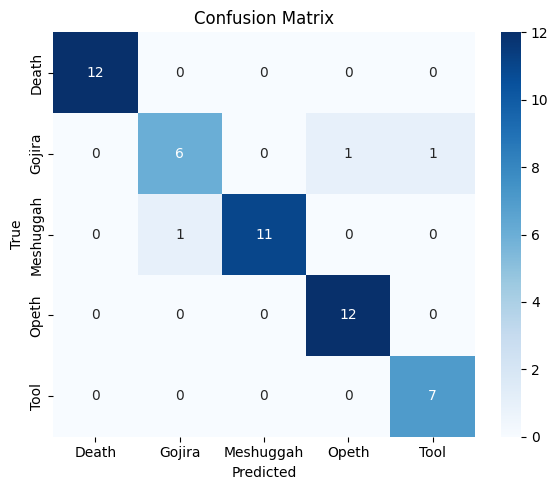

In [10]:
preds = trainer.predict(eval_dataset)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred, target_names=artists))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=artists, yticklabels=artists, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("../report/figures/confusion_matrix.pdf", bbox_inches="tight")
plt.show()

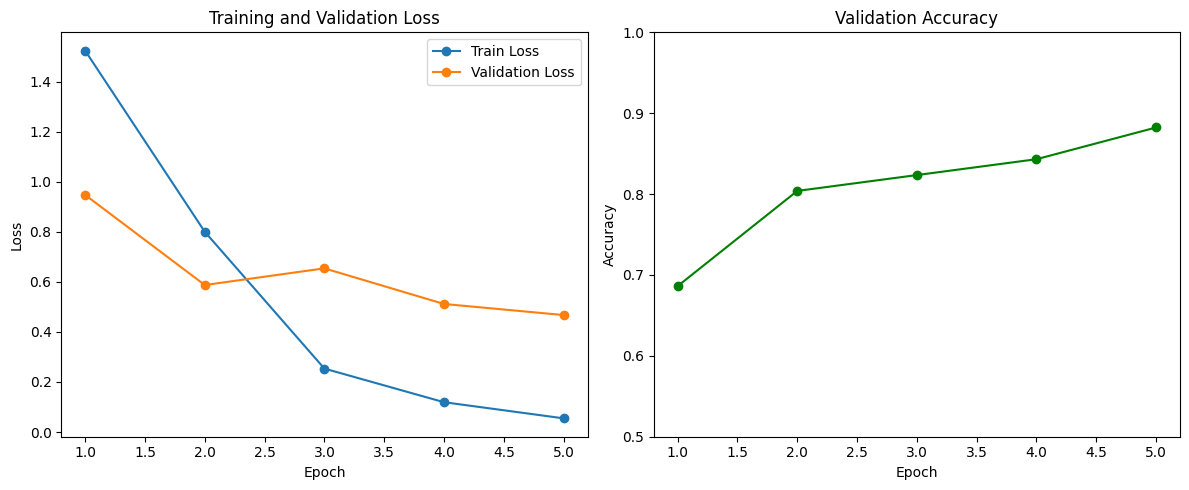

In [7]:
# Training curves from trainer log history
log = trainer.state.log_history

train_loss = [(e["epoch"], e["loss"]) for e in log if "loss" in e and "eval_loss" not in e]
eval_entries = [e for e in log if "eval_loss" in e]
eval_epochs = [e["epoch"] for e in eval_entries]
eval_loss = [e["eval_loss"] for e in eval_entries]
eval_acc = [e["eval_accuracy"] for e in eval_entries]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Aggregate train loss per epoch
train_epoch_loss = {}
for epoch, loss in train_loss:
    e = int(epoch) if epoch == int(epoch) else int(epoch) + 1
    train_epoch_loss.setdefault(e, []).append(loss)
train_epochs_agg = sorted(train_epoch_loss.keys())
train_loss_agg = [np.mean(train_epoch_loss[e]) for e in train_epochs_agg]

ax1.plot(train_epochs_agg, train_loss_agg, "o-", label="Train Loss")
ax1.plot(eval_epochs, eval_loss, "o-", label="Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()

ax2.plot(eval_epochs, eval_acc, "o-", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig("../report/figures/training_curves.pdf", bbox_inches="tight")
plt.show()

## Save

In [8]:
trainer.save_model("./classifier_output/best_model")
tokenizer.save_pretrained("./classifier_output/best_model")
print("Saved to ./classifier_output/best_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./classifier_output/best_model
